In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.4 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO
import os
from IPython.display import display, Image, clear_output
clear_output()
!yolo checks

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.9/112.6 GB disk)

OS                     Linux-6.6.105+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   38.9/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 15095MiB
GPU count              1
CUDA                   12.6

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.12.0.88>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.9.0+cu126>=1.8.0
torch                  ✅ 2.9.0+cu126!=2.4.0,>=1.8.0; sys_platform == "win32"


In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="hnrP4b2ZPs2NVzmswPfi")
project = rf.workspace("projects-erksv").project("final_license_plate-q6nlt")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final_License_Plate-3 in yolov8:: 100%|██████████| 5090/5090 [00:01<00:00, 3286.29it/s]


loading Roboflow workspace...
loading Roboflow project...


In [11]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=30 imgsz=640

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Final_License_Plate-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

In [20]:
from google.colab import files

# Path to your trained model
model_path = '/content/runs/detect/train/weights/best.pt'

# Download to your local machine
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

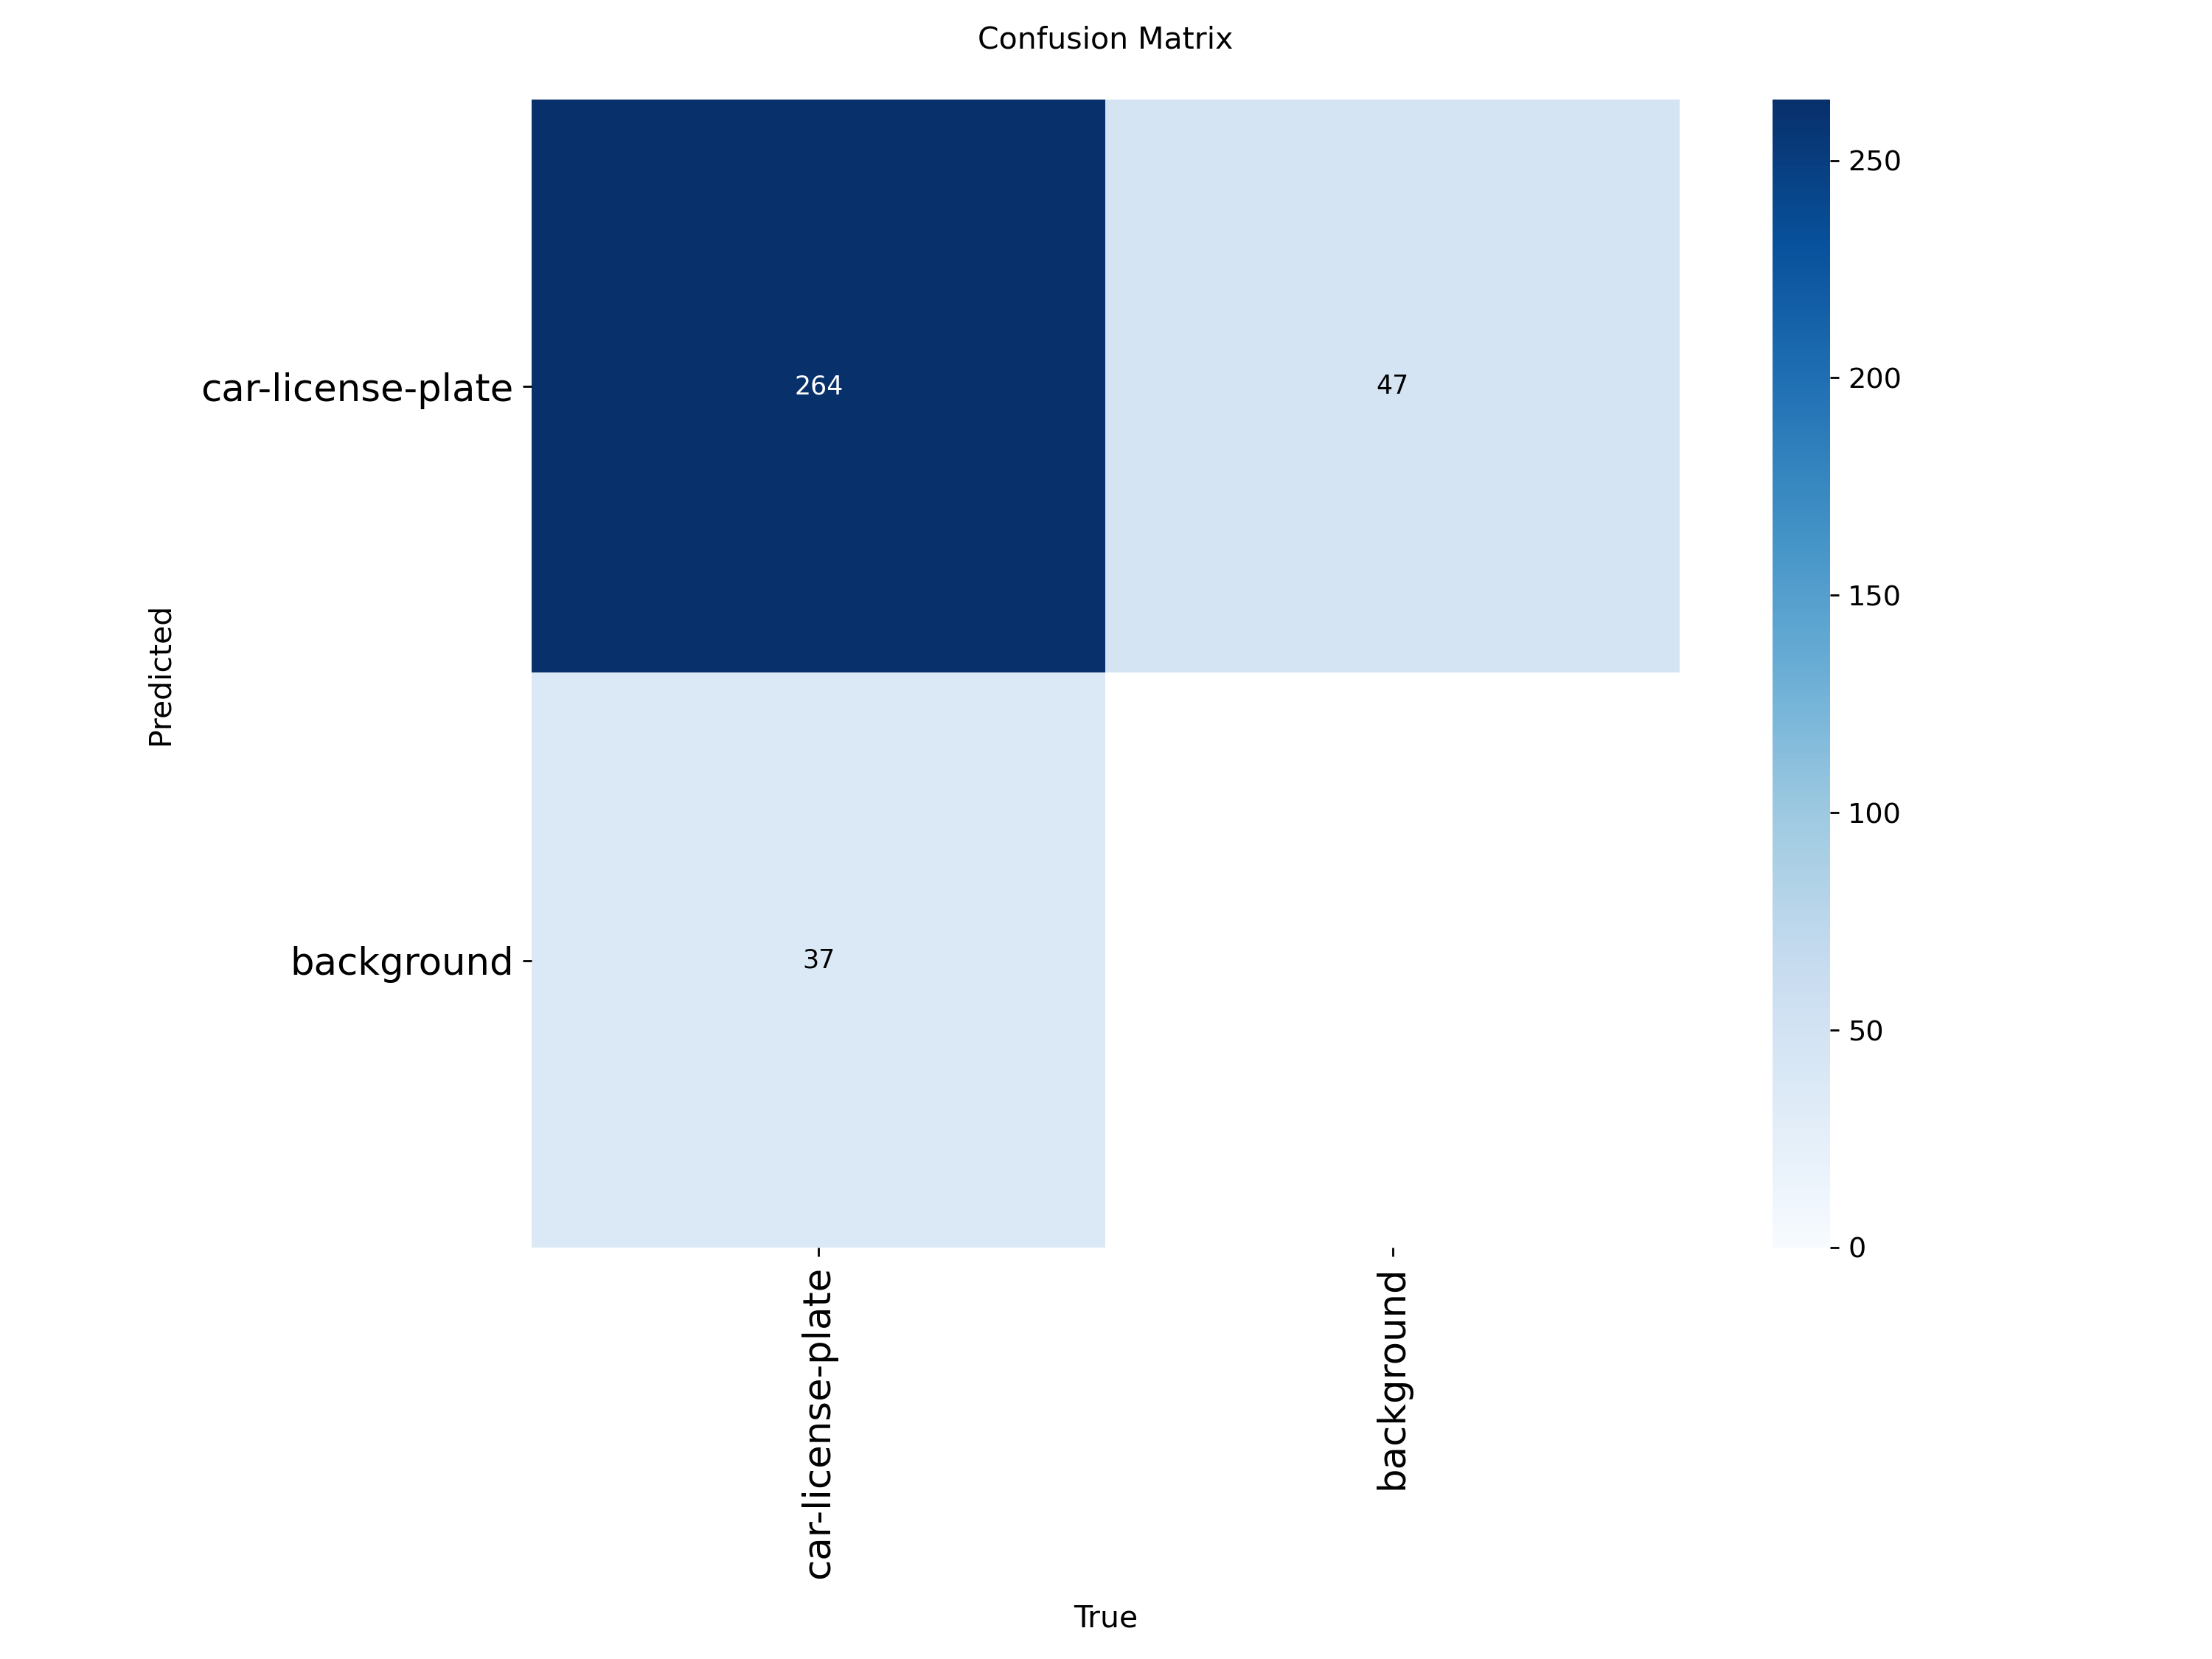

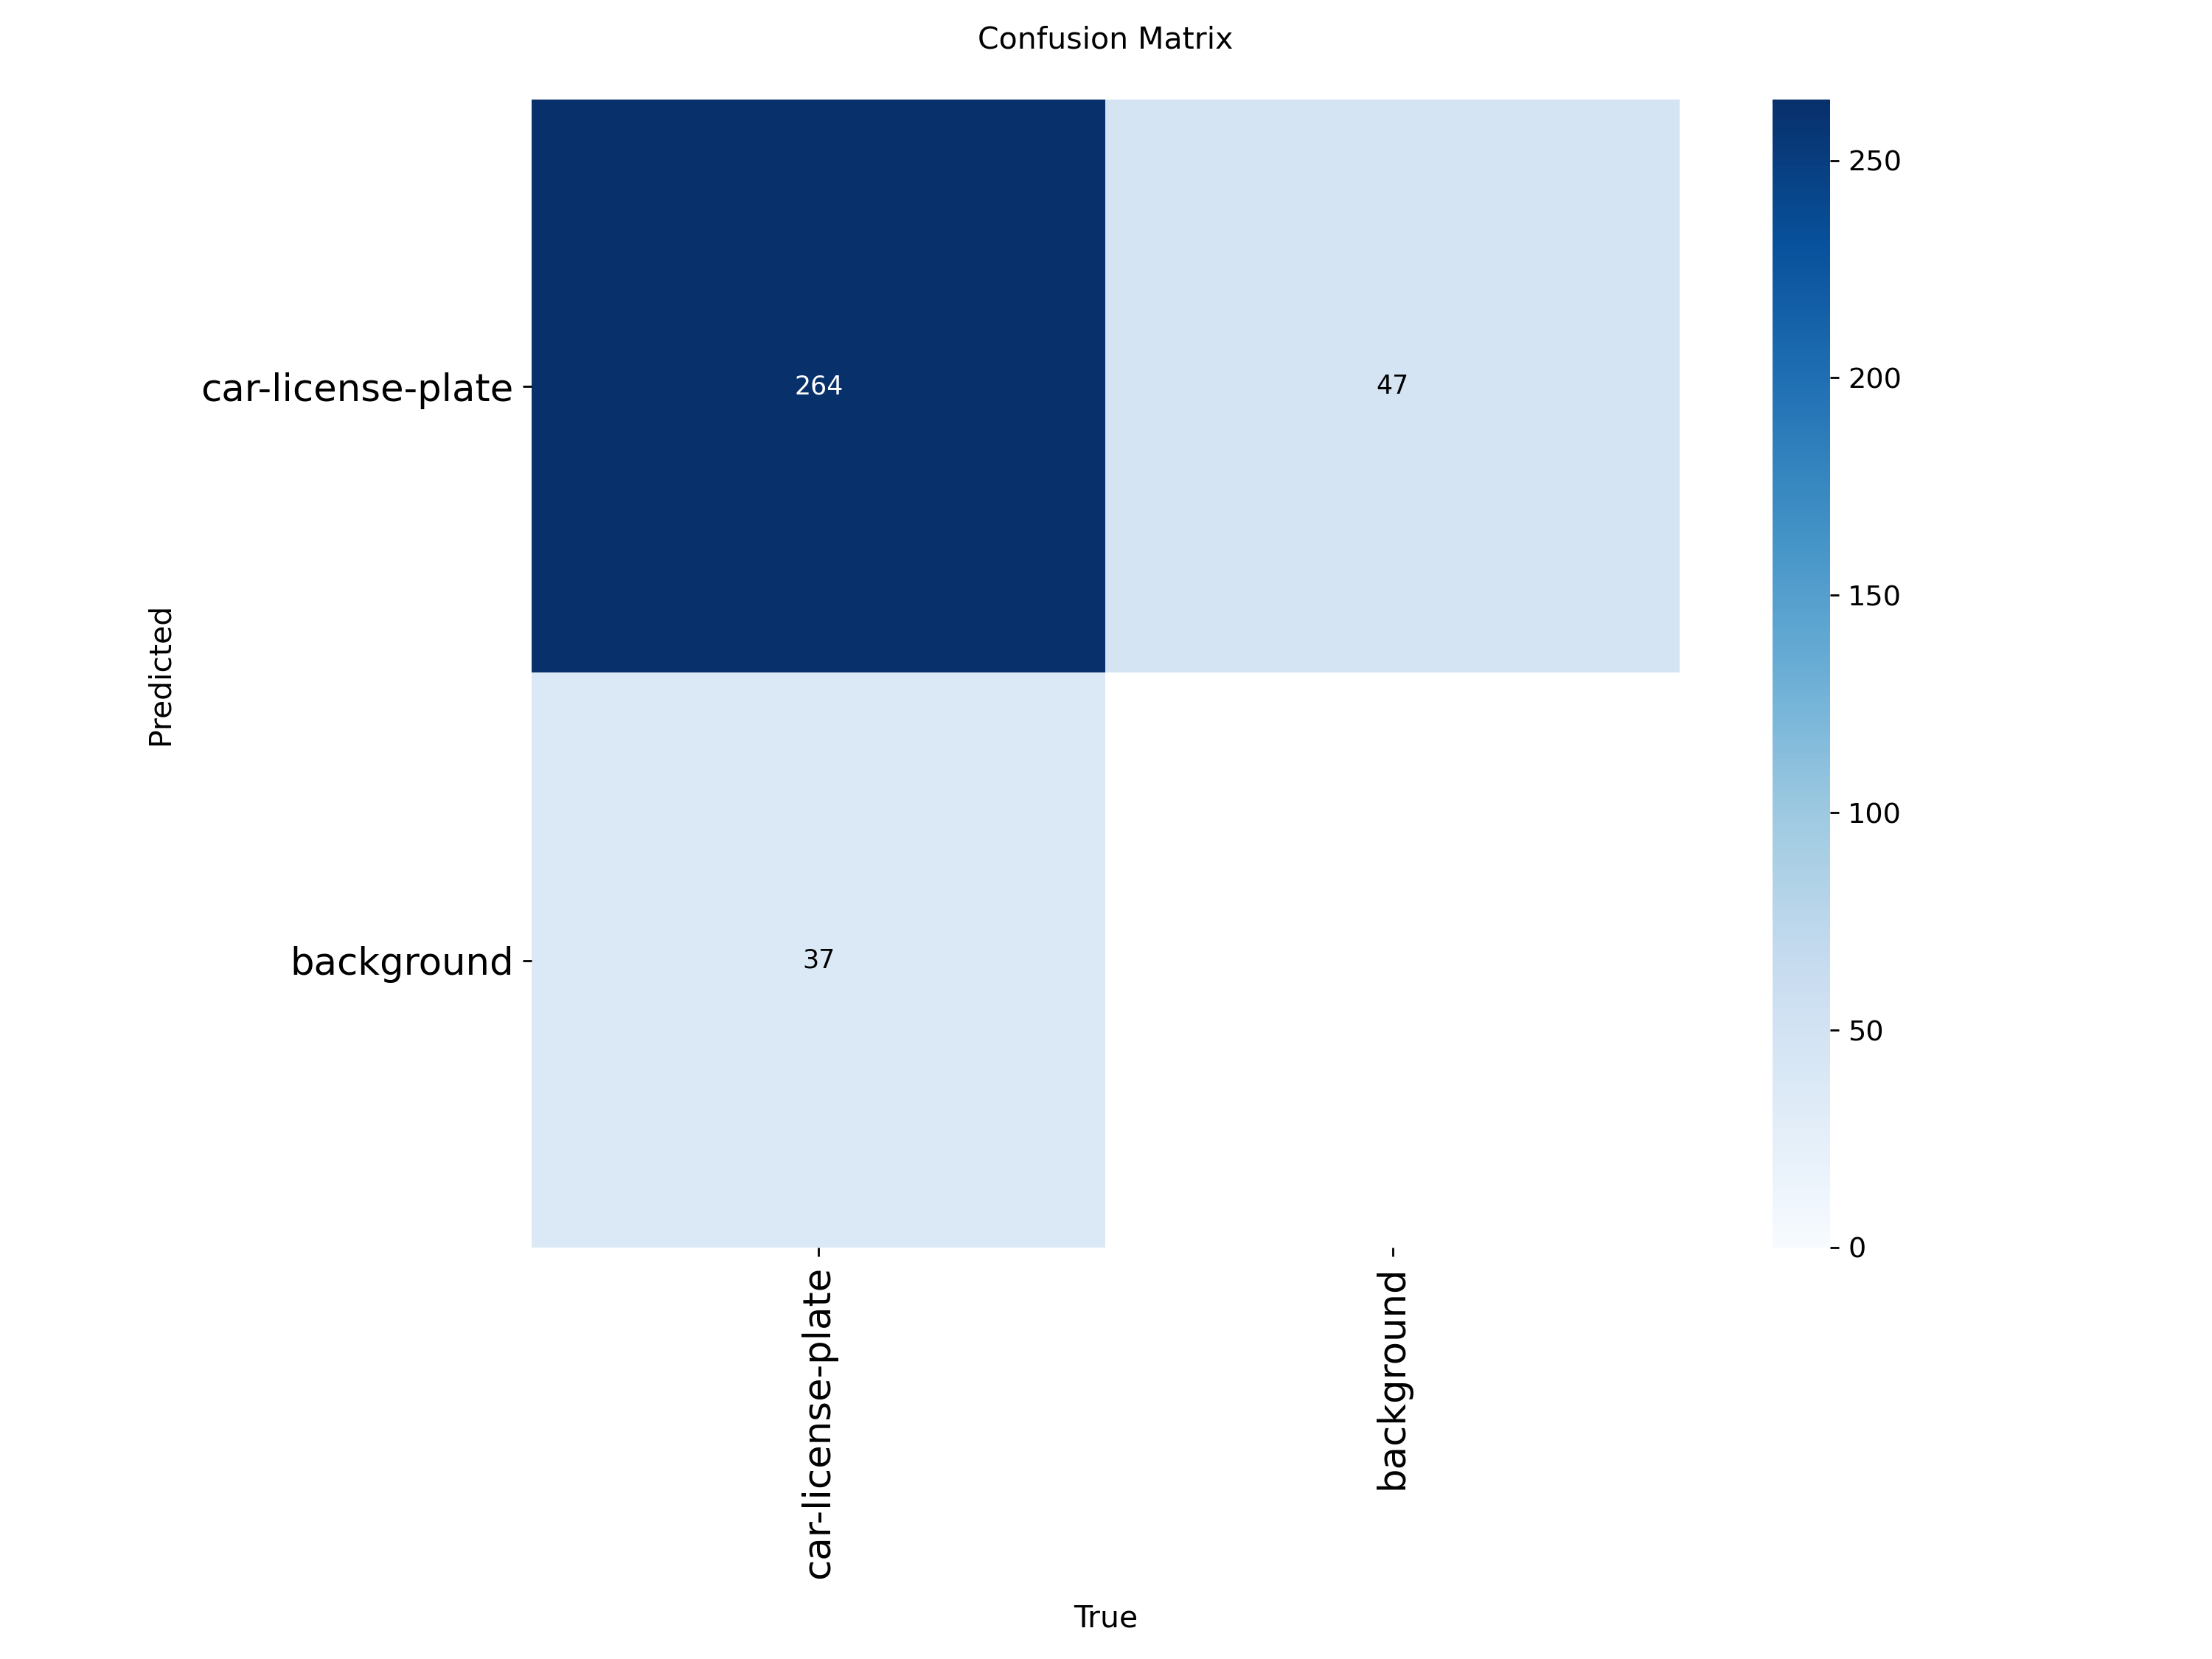

In [12]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

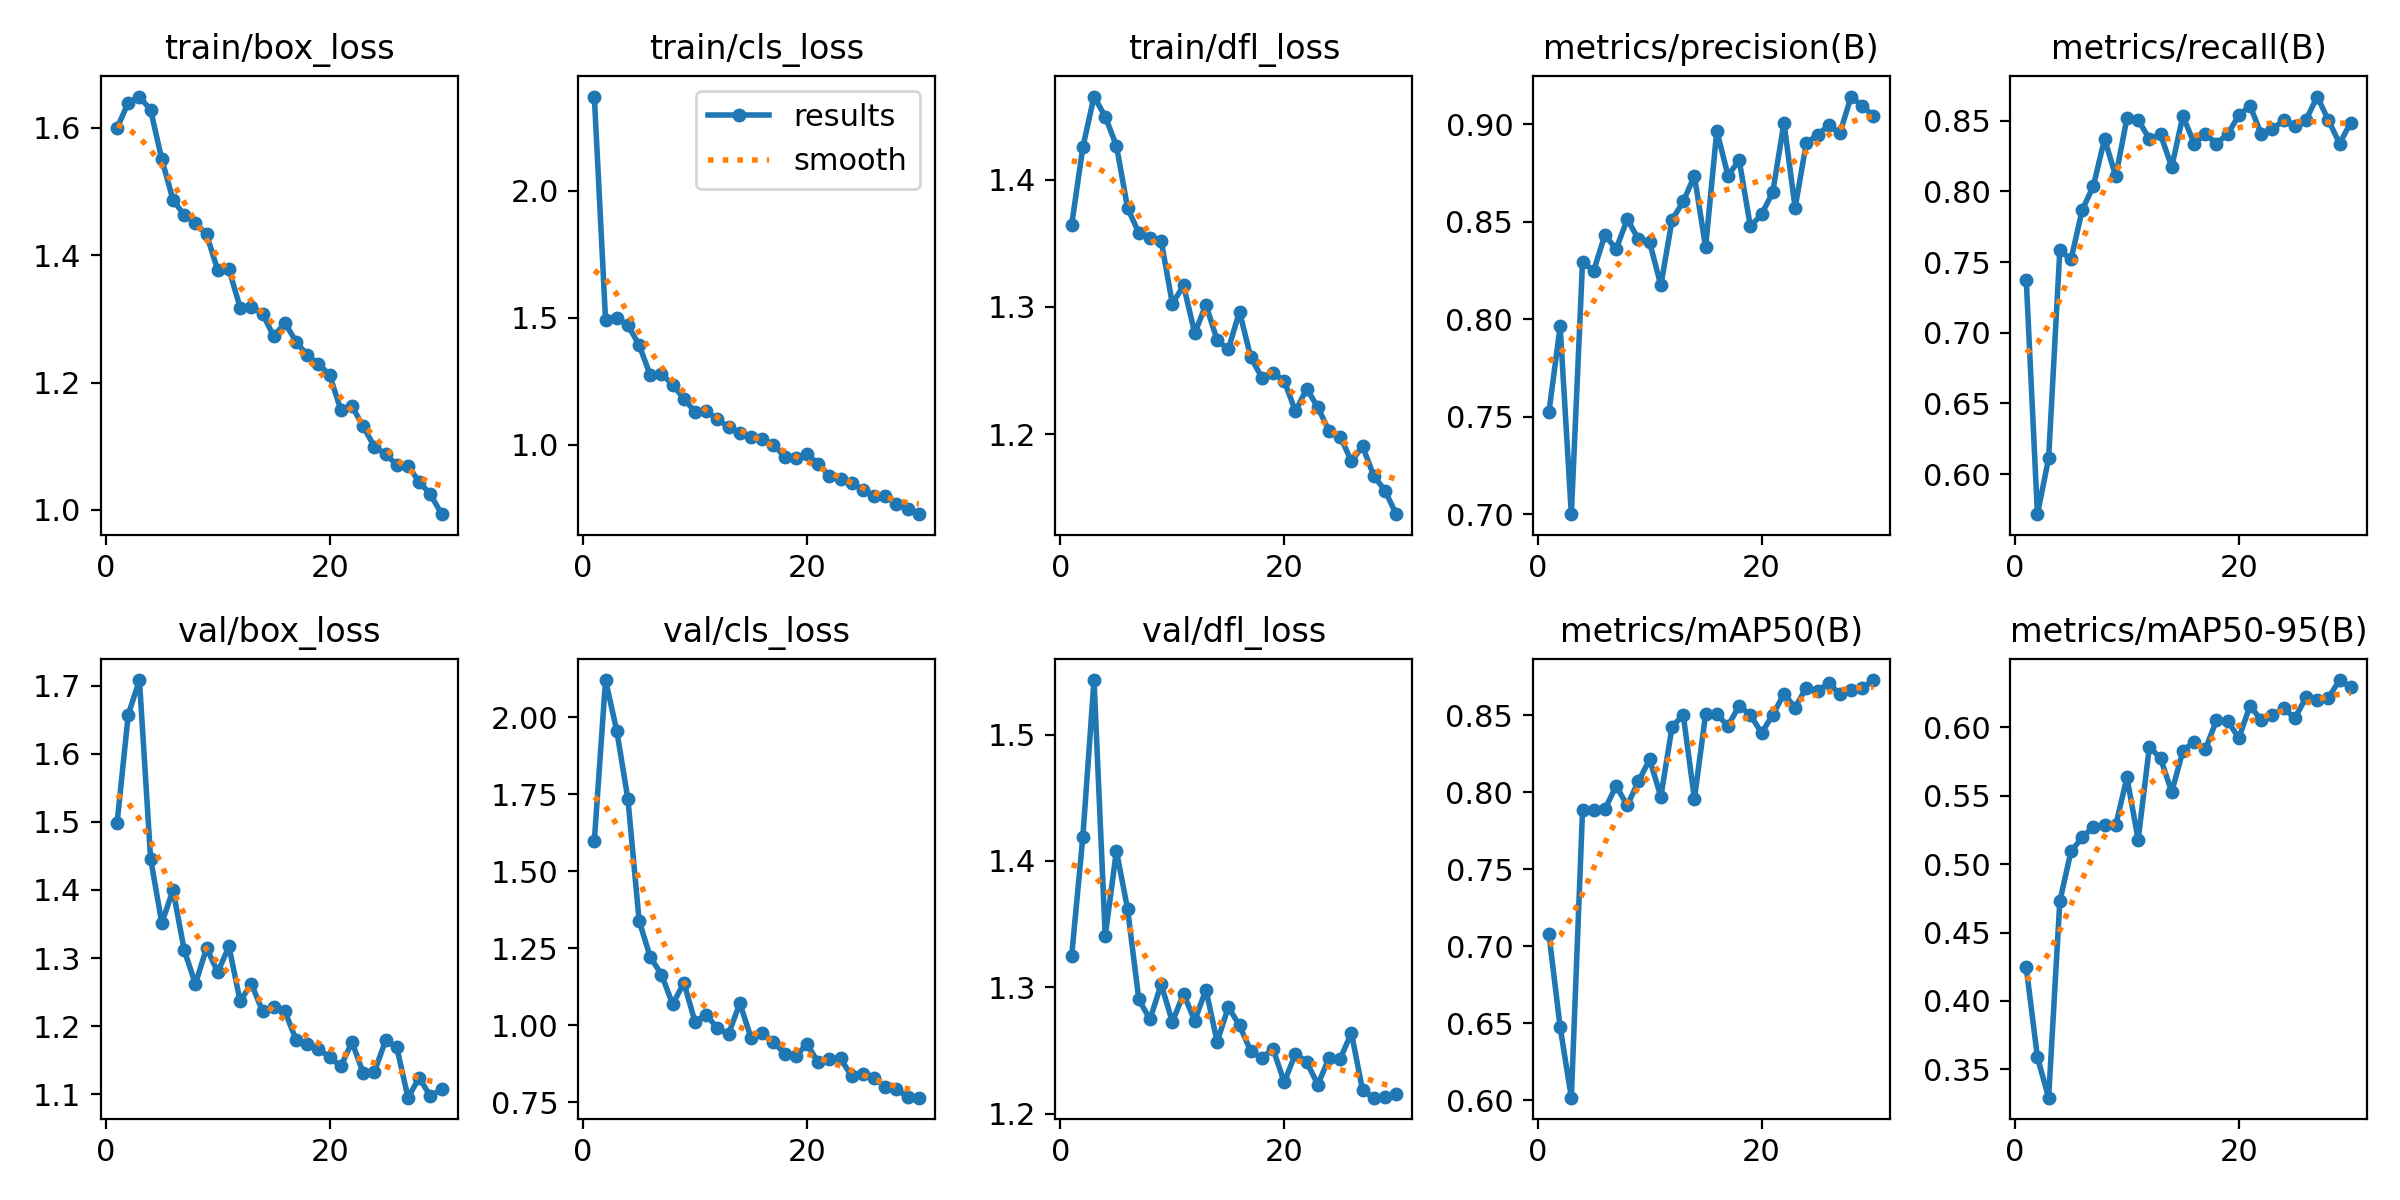

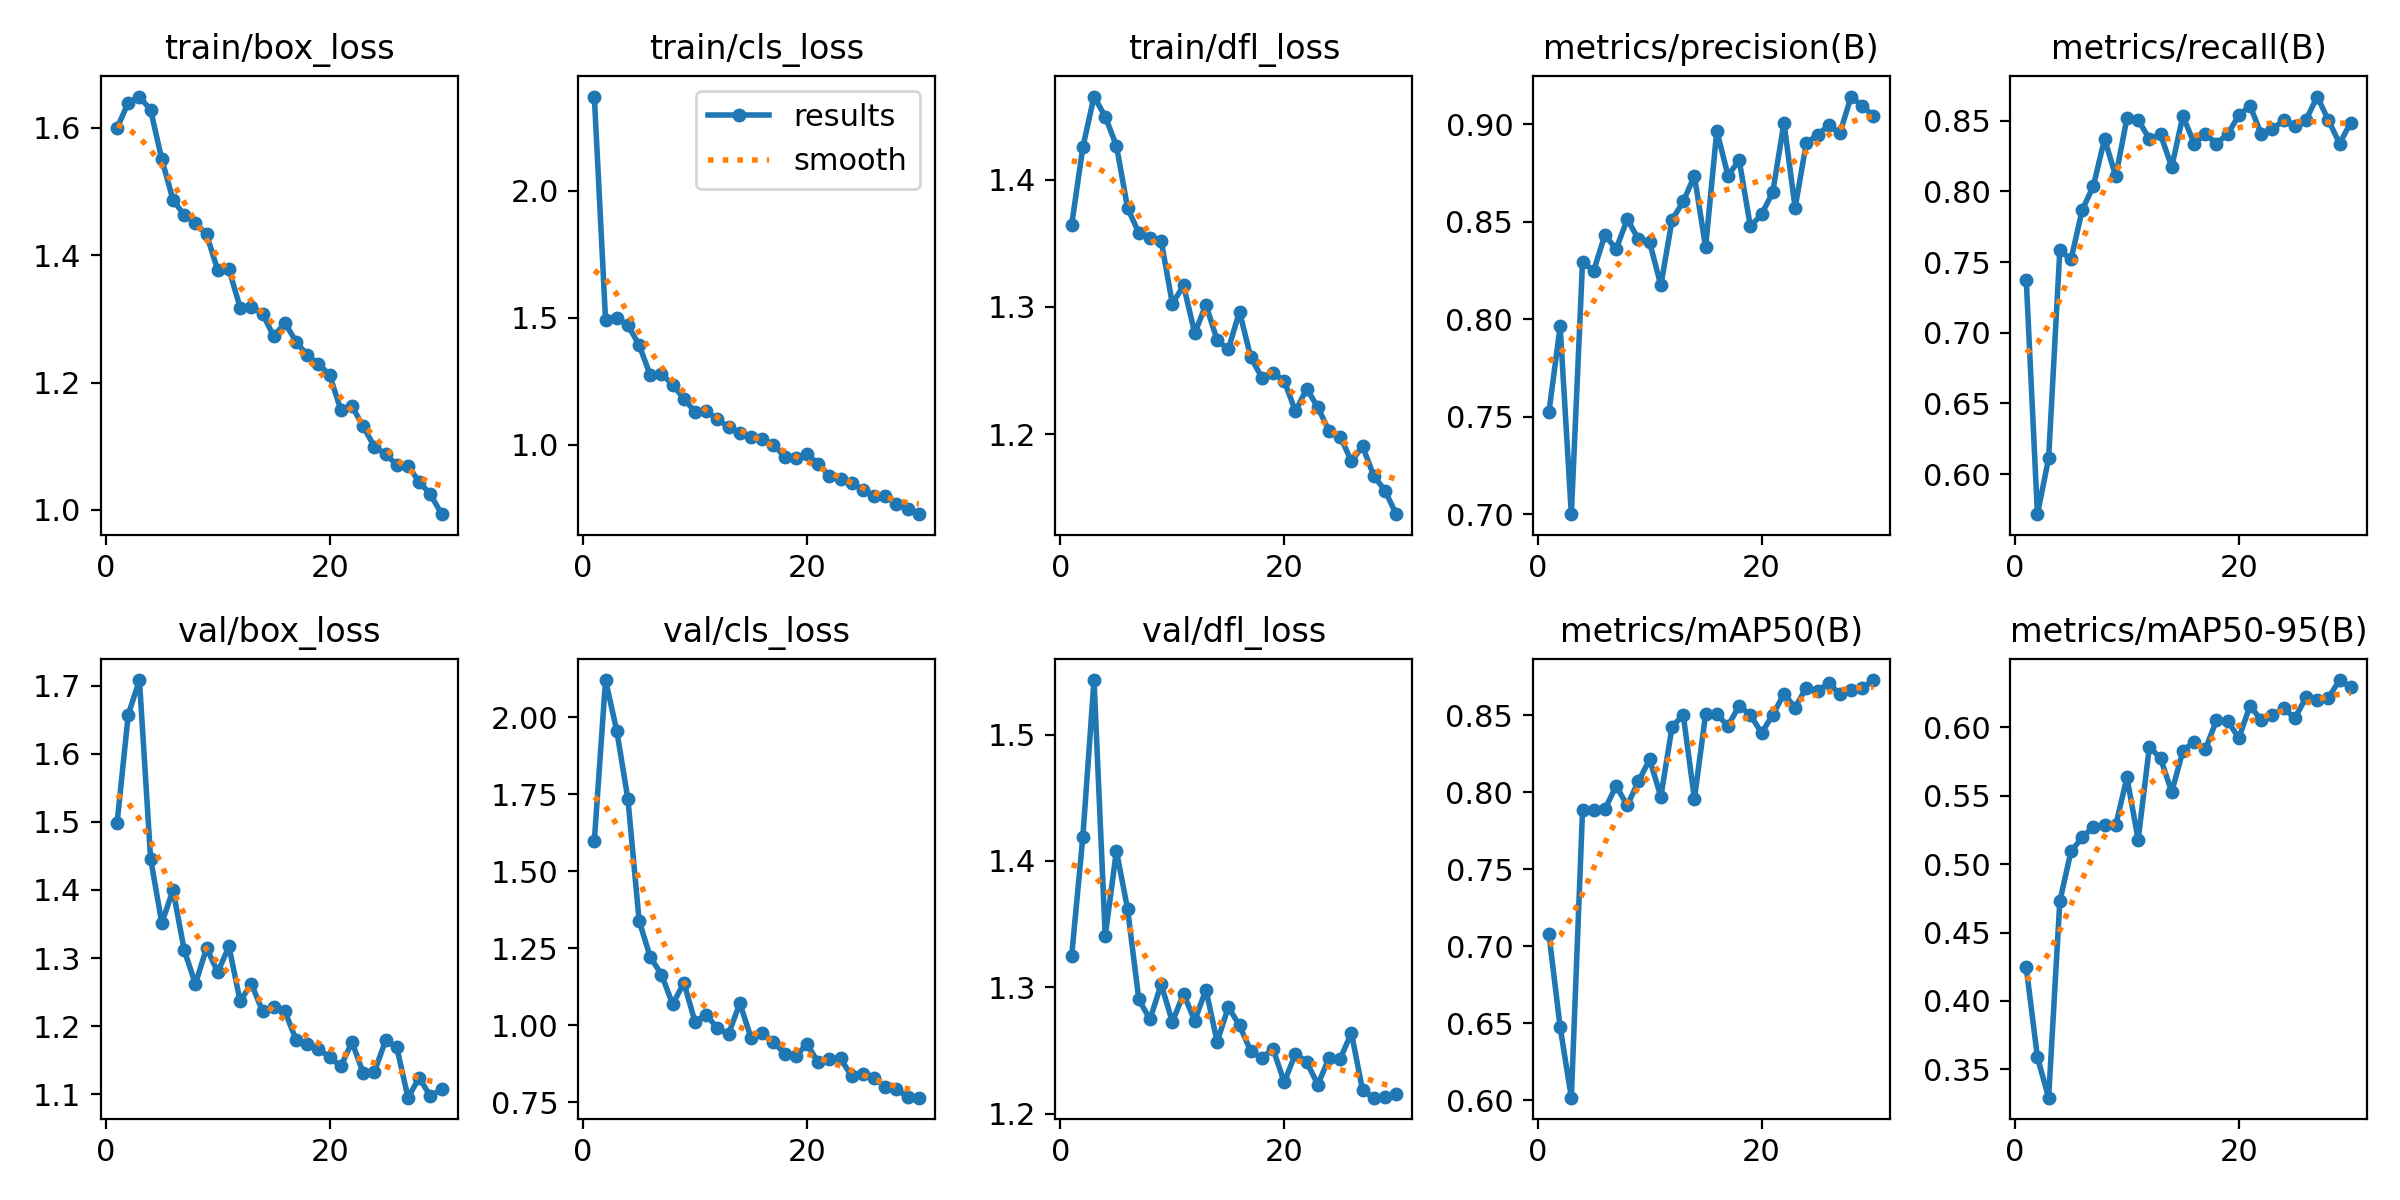

In [13]:
Image(filename=f'/content/runs/detect/train/results.png', width=600)

In [21]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/Final_License_Plate-3/data.yaml

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1232.3±631.3 MB/s, size: 27.0 KB)
val: Scanning /content/Final_License_Plate-3/valid/labels.cache... 293 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 293/293 4.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 73, len(boxes) = 301. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.4it/s 5.7s
                   all        293        301      0.897      0.857      0.871      0.635
Speed: 1.9ms preprocess, 9.0ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect

In [22]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source=/content/Final_License_Plate-3/test/images save=True

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/125 /content/Final_License_Plate-3/test/images/-201140001-SS-3365966-2024_04_26-07_56_17-RHB968GP-0-_jpg.rf.b4355b1b183e49890b552c3cbfa6e316.jpg: 384x640 1 car-license-plate, 45.4ms
image 2/125 /content/Final_License_Plate-3/test/images/-201140002-SS-3366186-2024_04_26-08_47_04-FB96TMGP-67_68_68_68_67_65_0_0_0_0_0_0_0_0_0_0_0_0_0-_jpg.rf.4021f90b9b8c9bf18b5495e1f83943c3.jpg: 384x640 1 car-license-plate, 10.7ms
image 3/125 /content/Final_License_Plate-3/test/images/-201140003-GS-3093087-2024_02_27-10_51_37-JS50VJGP-_jpg.rf.83d7160595fa6850556df8744a713ccc.jpg: 480x640 1 car-license-plate, 41.8ms
image 4/125 /content/Final_License_Plate-3/test/images/-201140003-GS-3093087-2024_02_27-11_12_05-KS2GP-_jpg.rf.0a05fe1fa4257d5754fff610d96d7027.jpg: 480x640 1 car-license-plate, 12.8ms
image 5/125 /content/Final_License_Plat

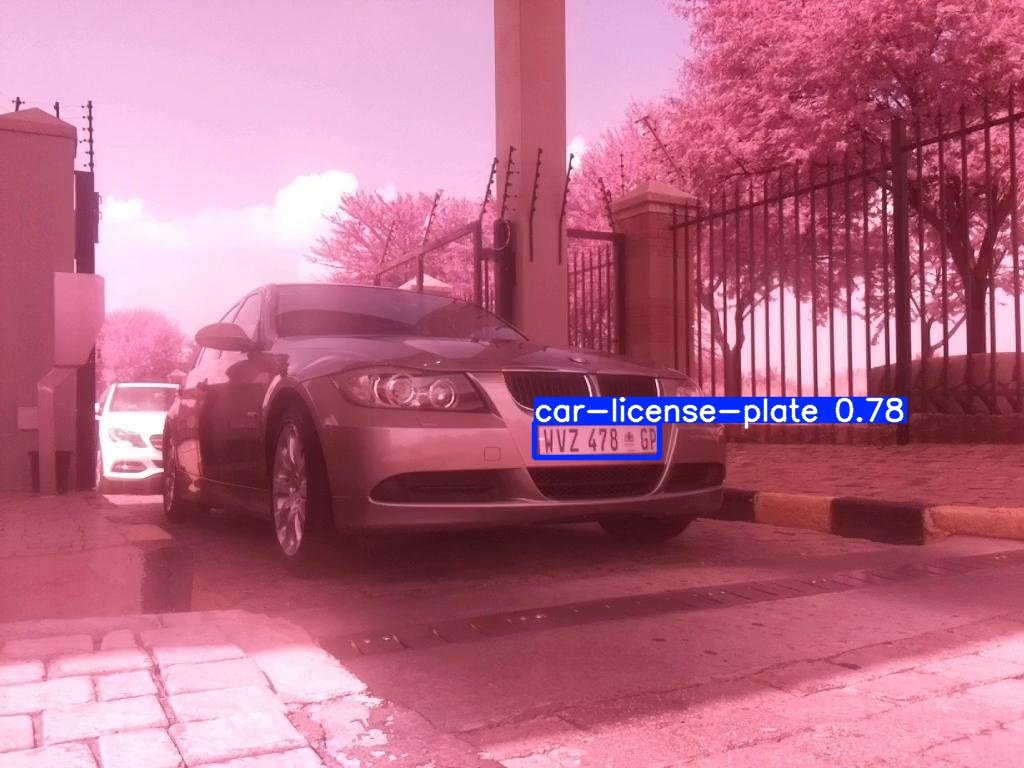

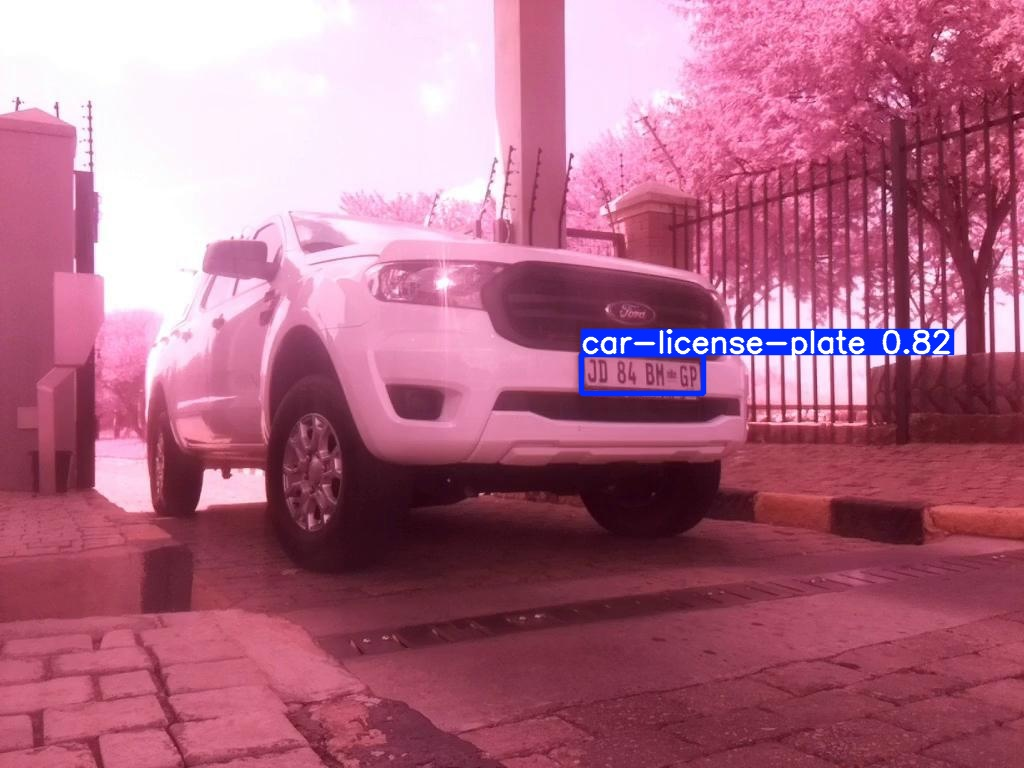

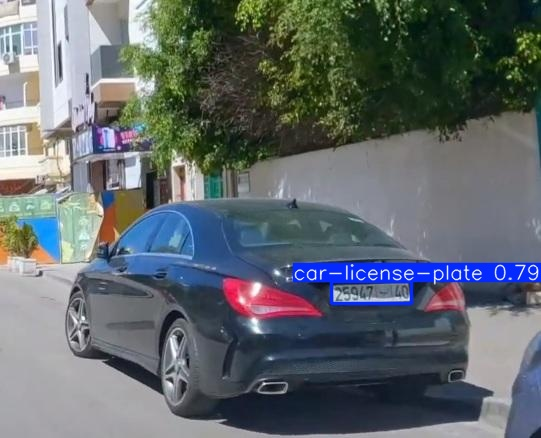

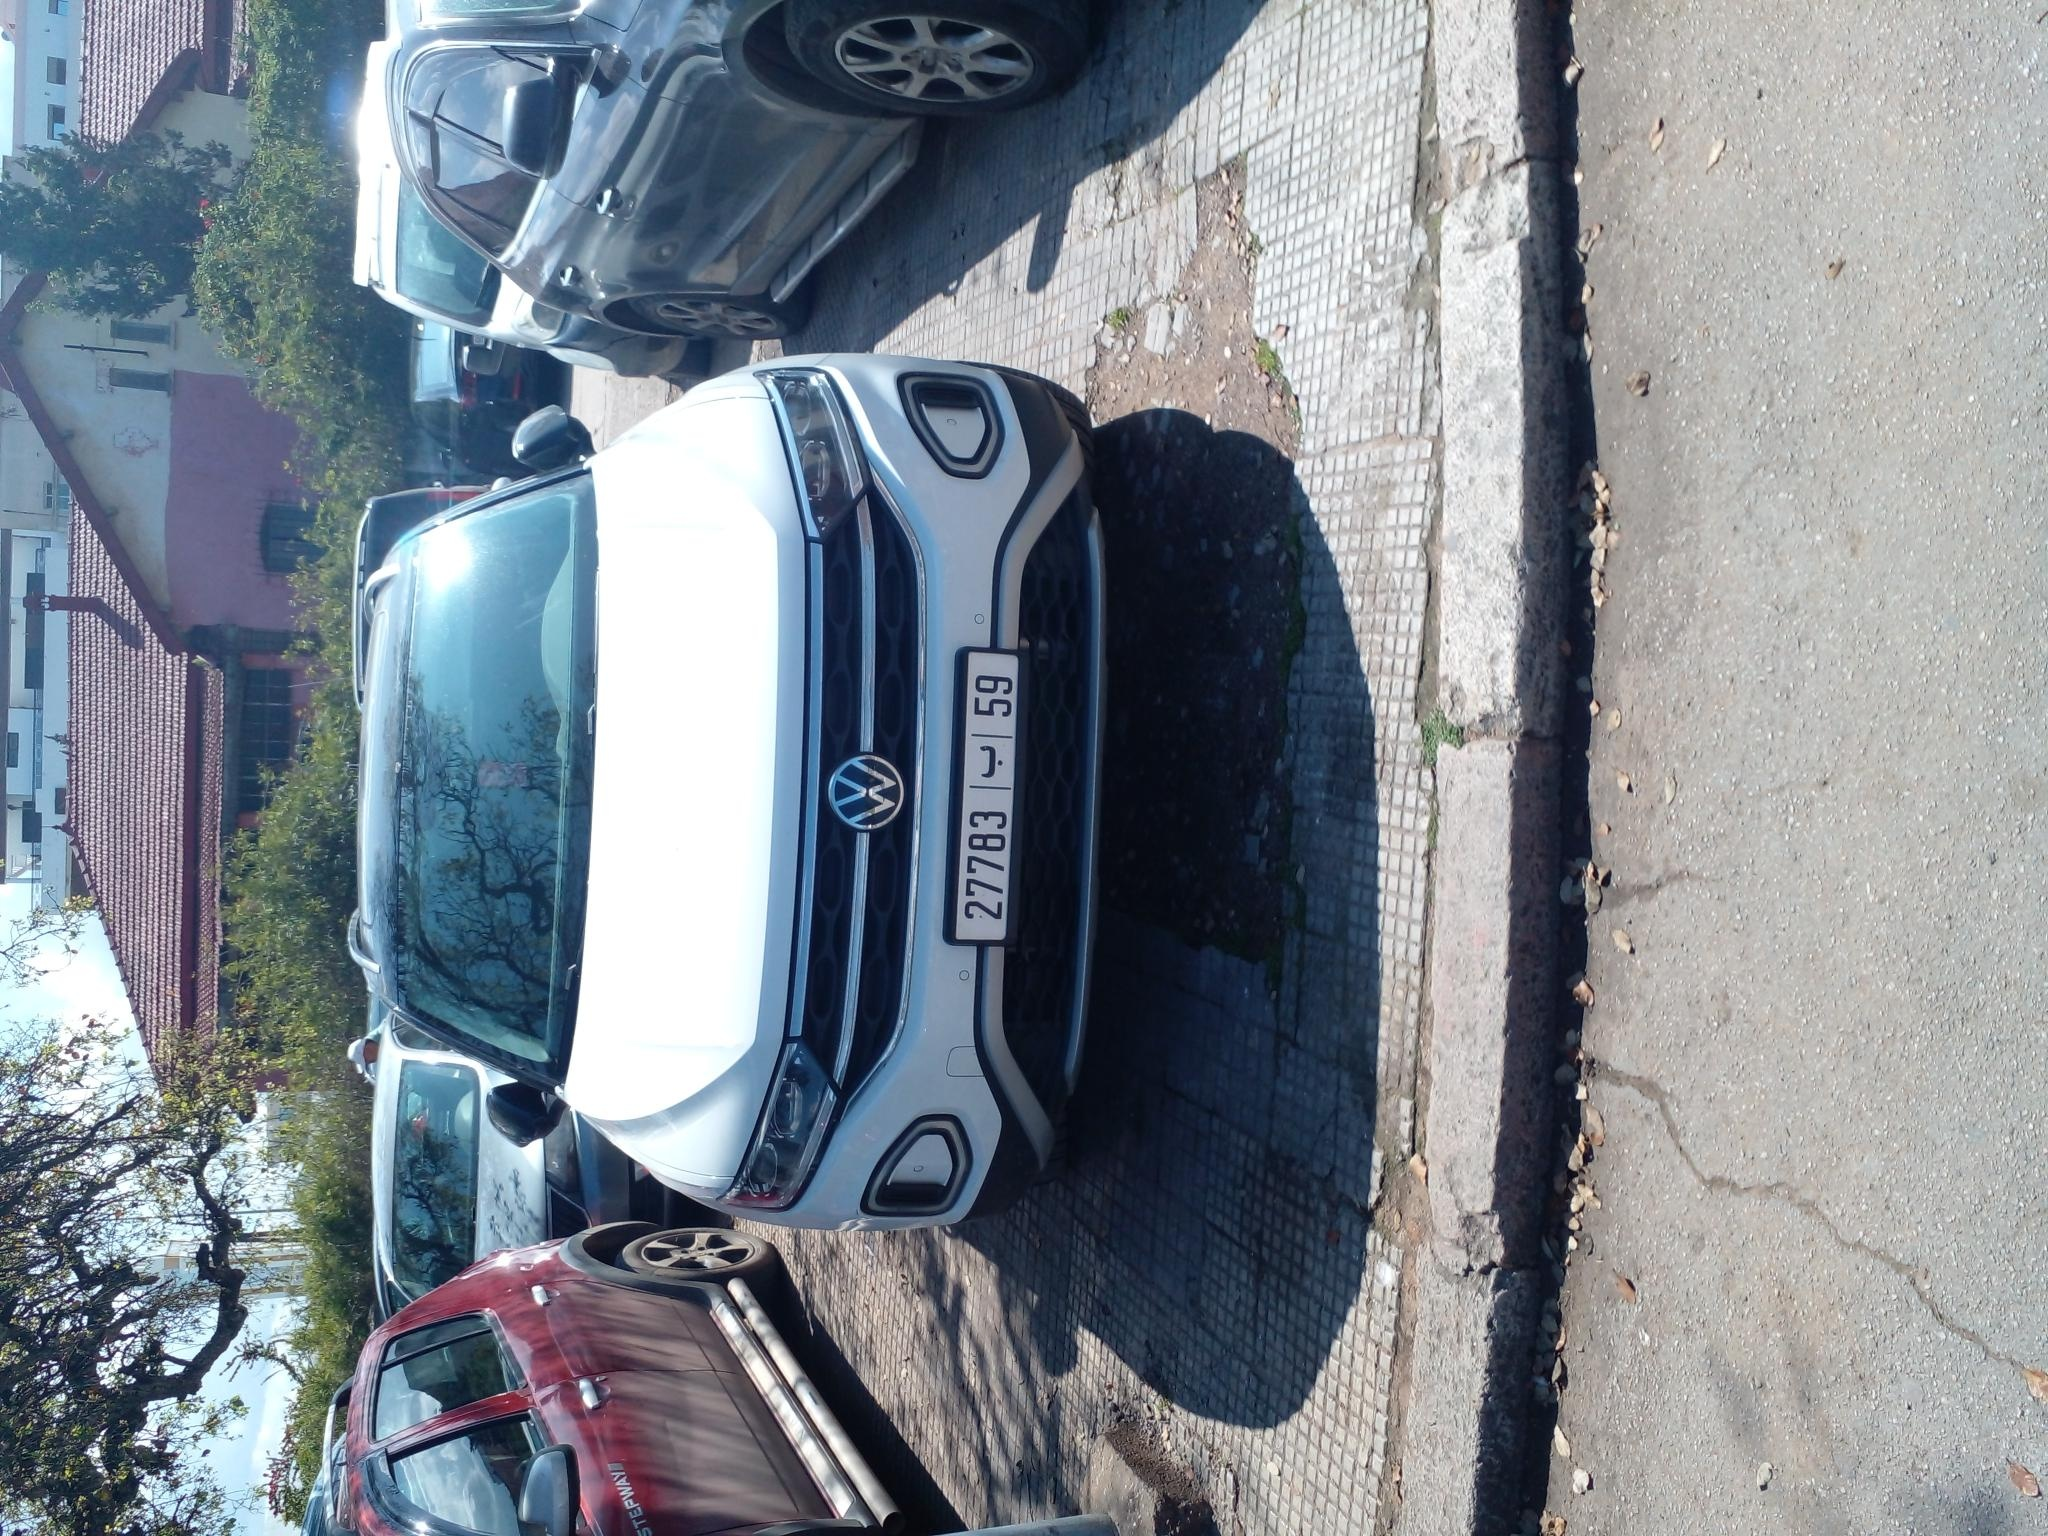

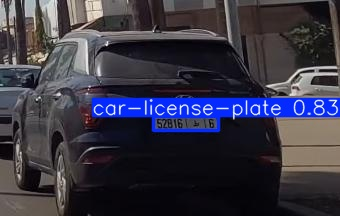

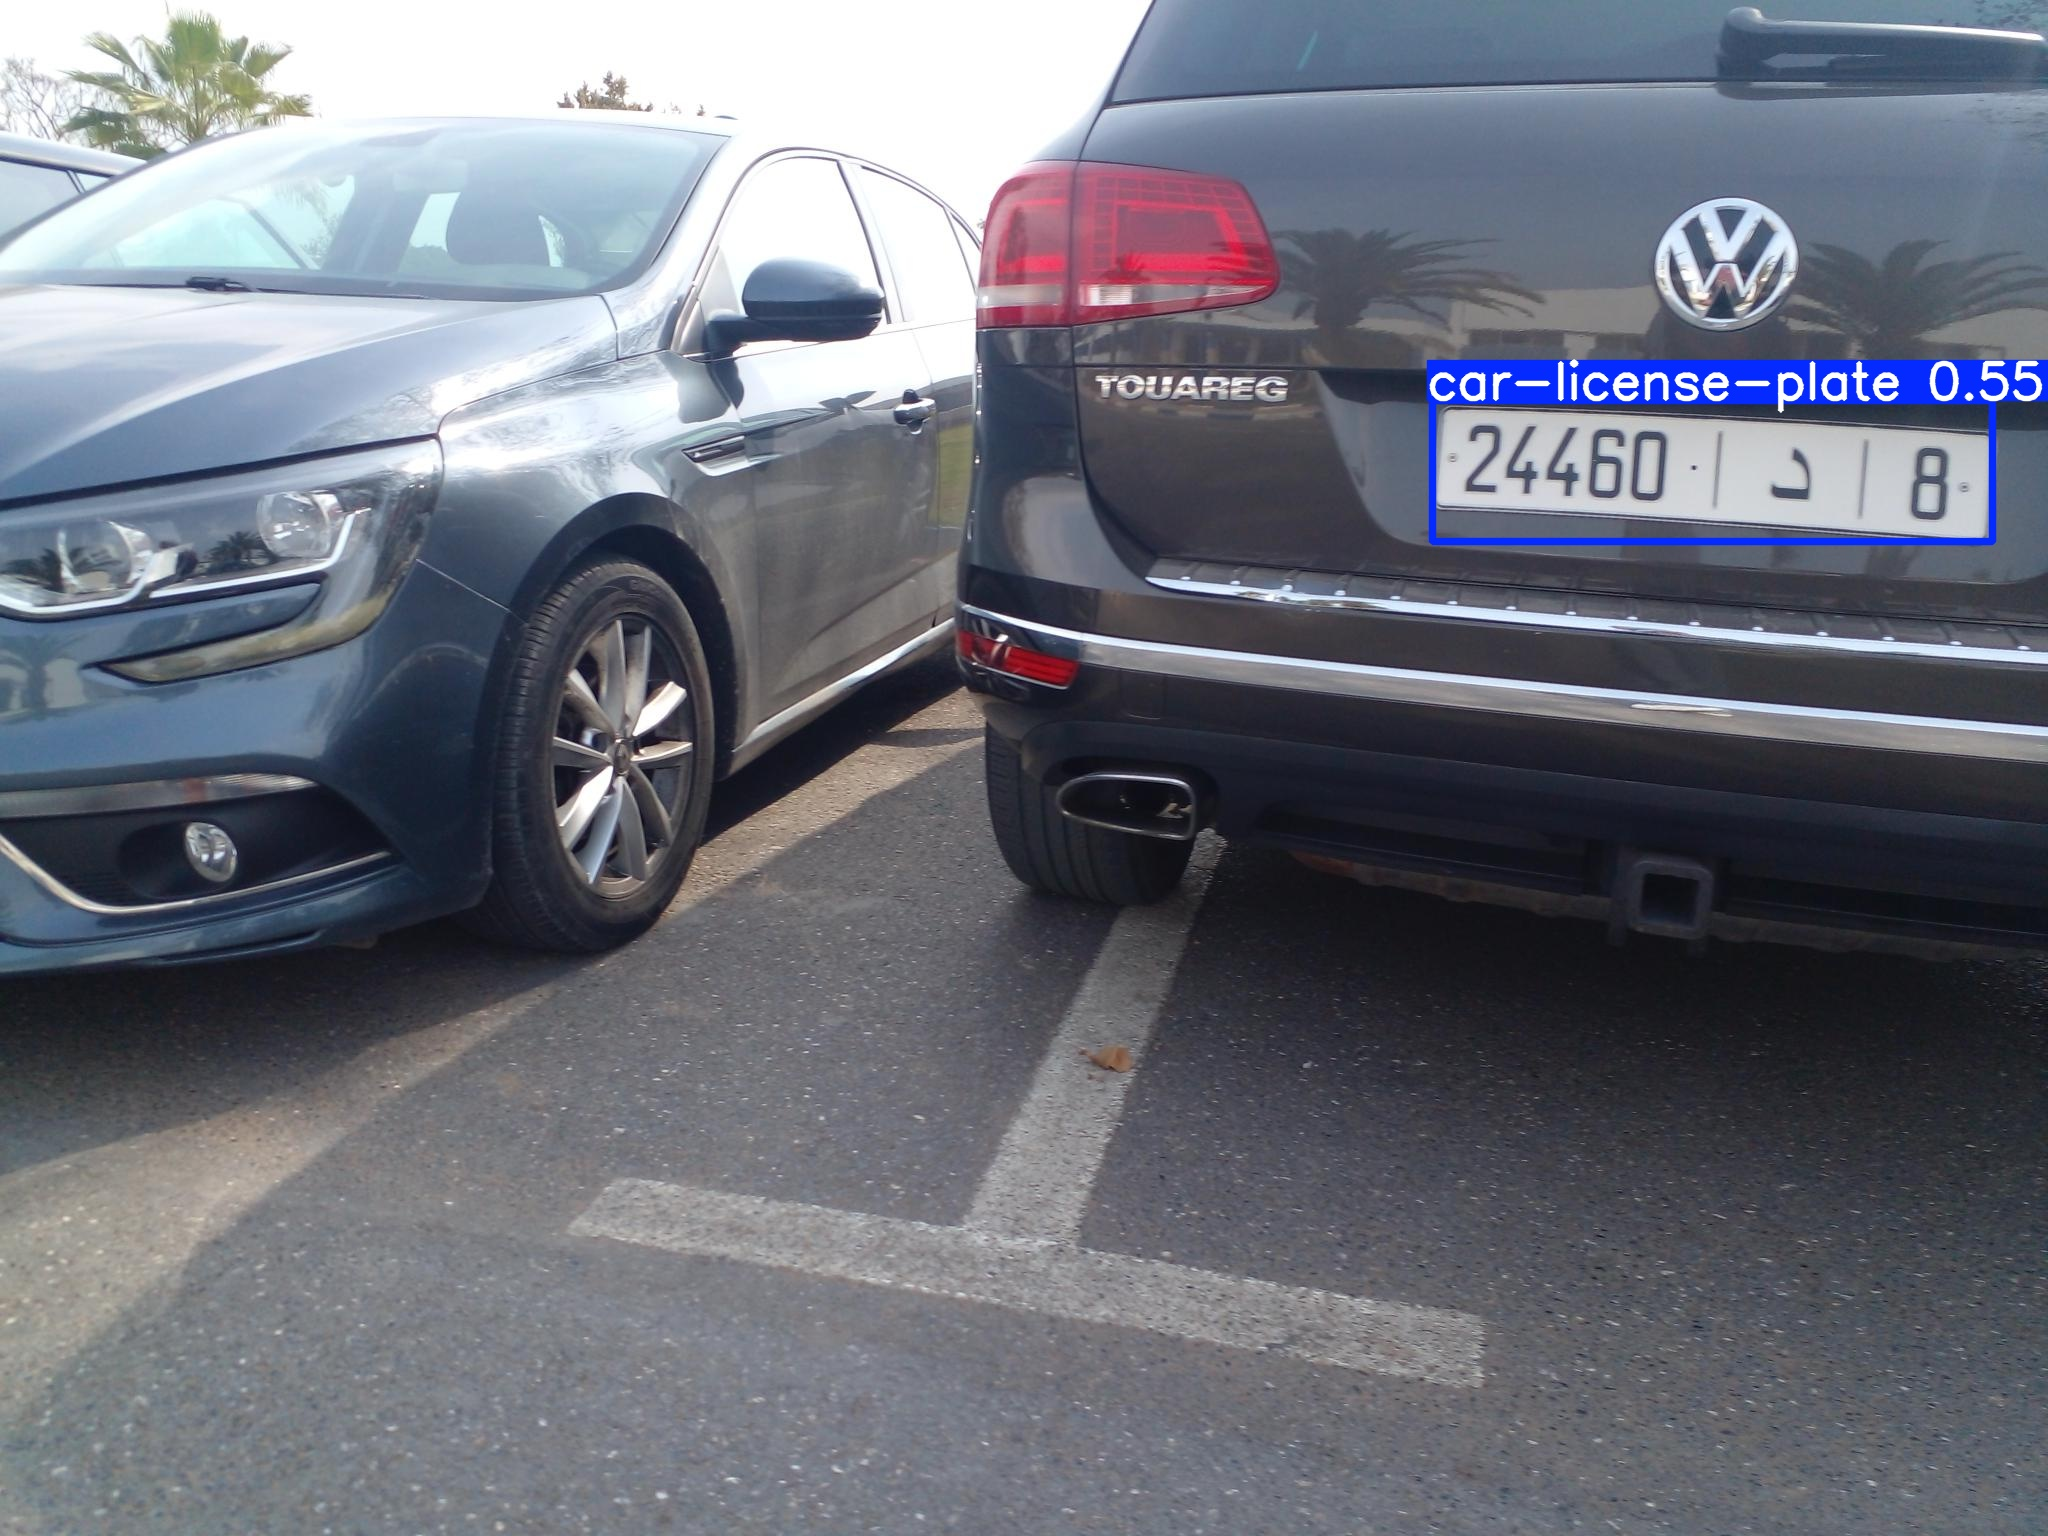

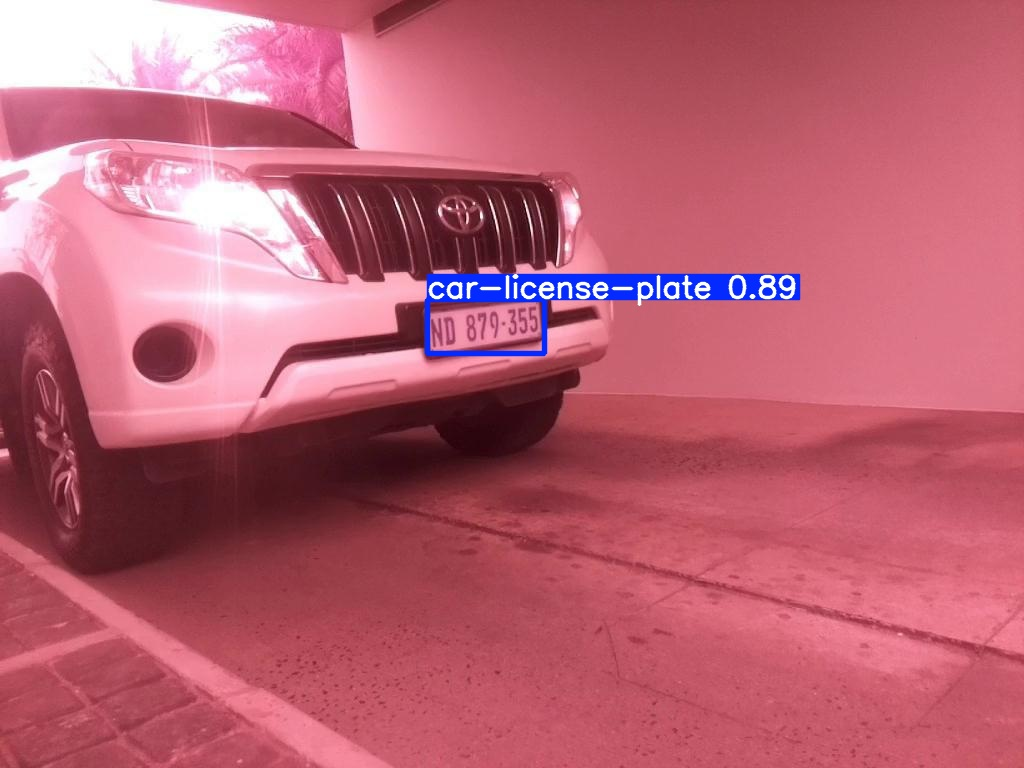

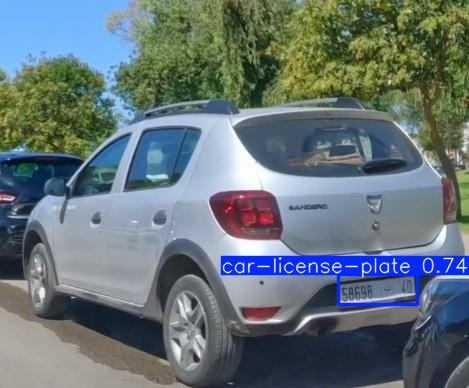

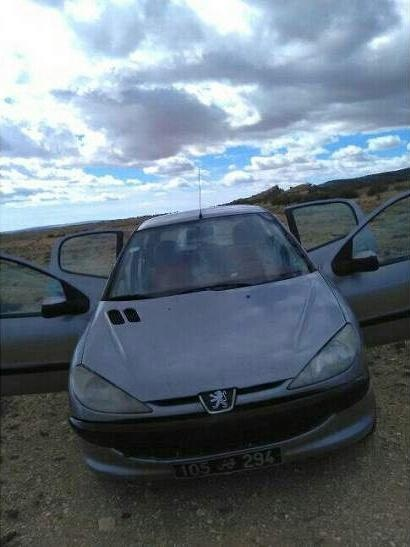

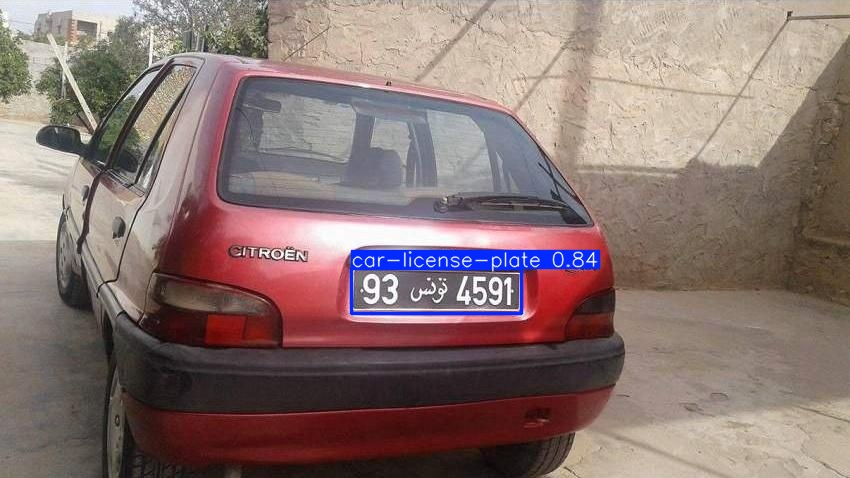

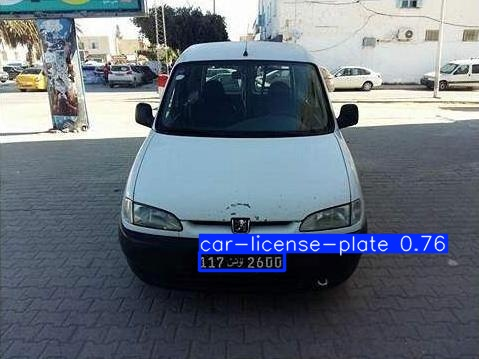

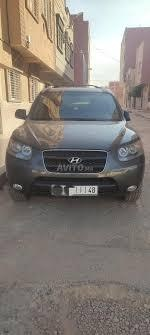

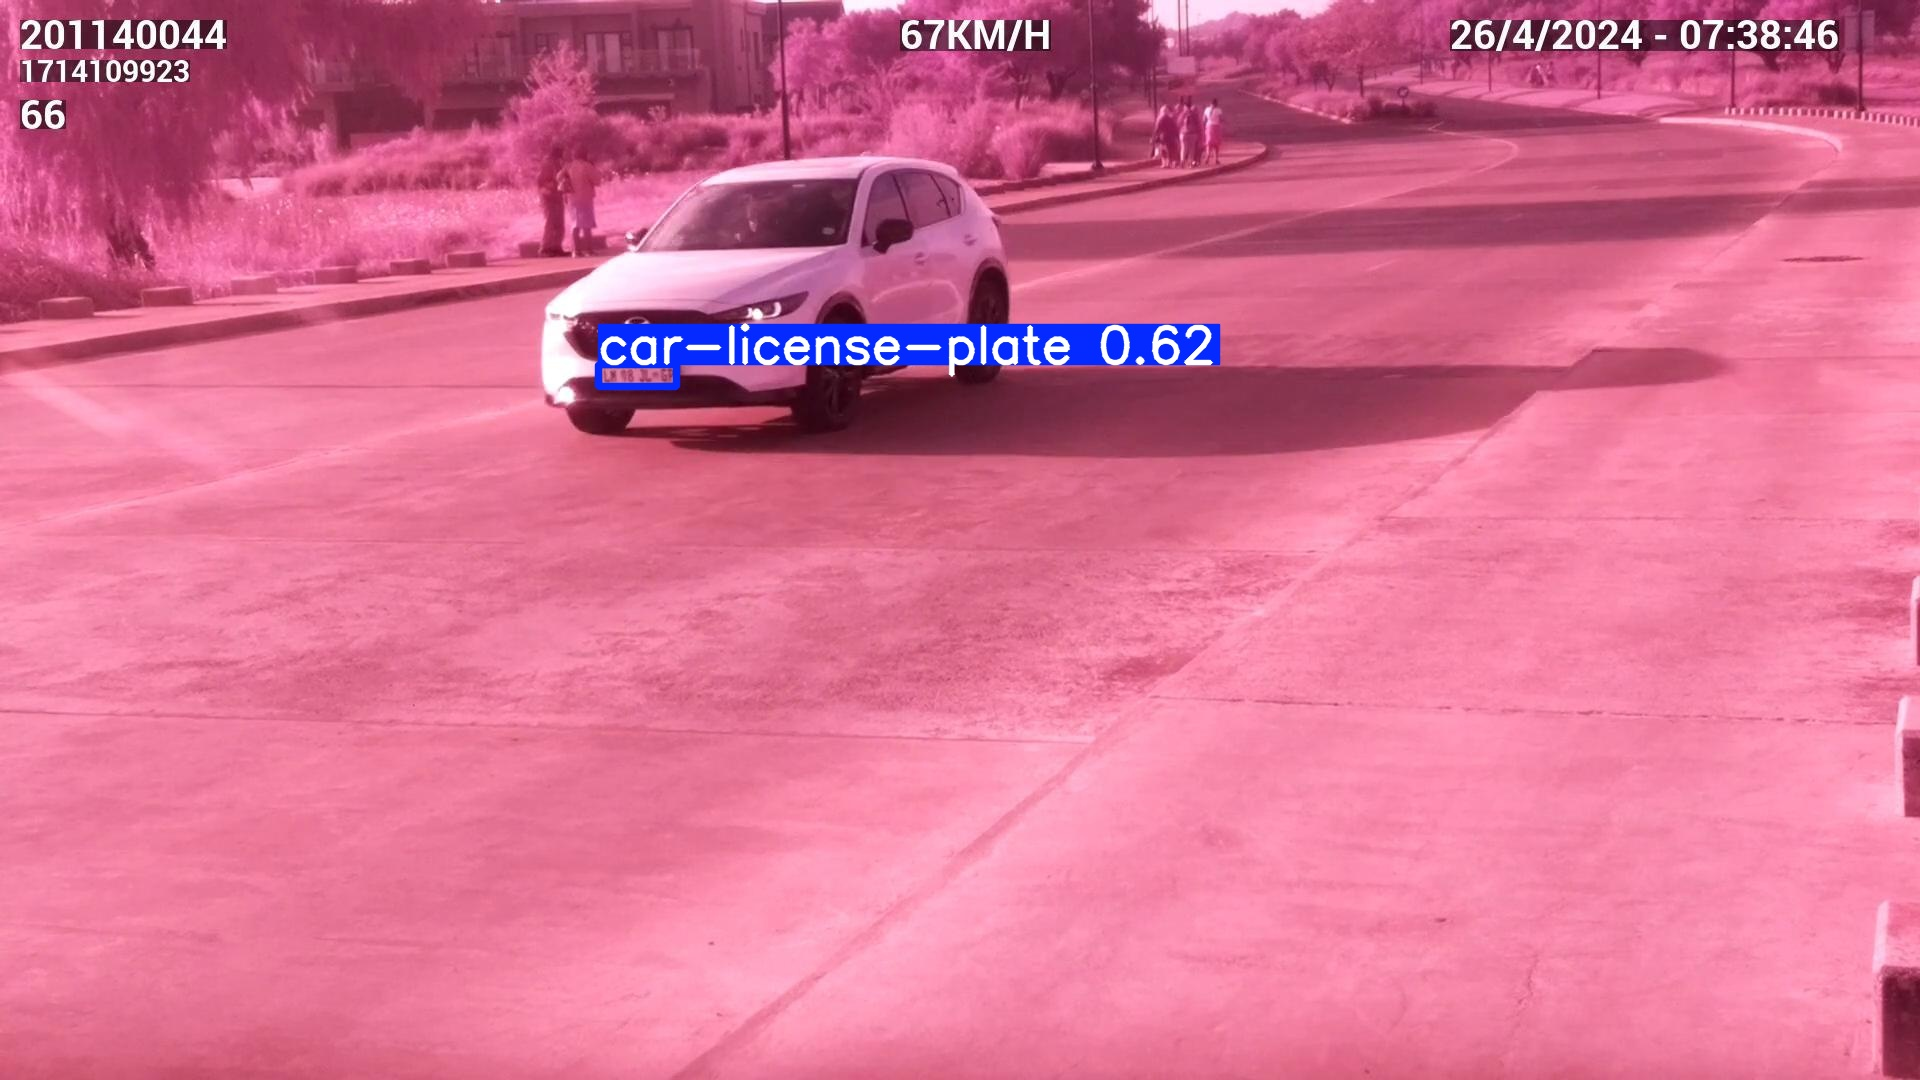

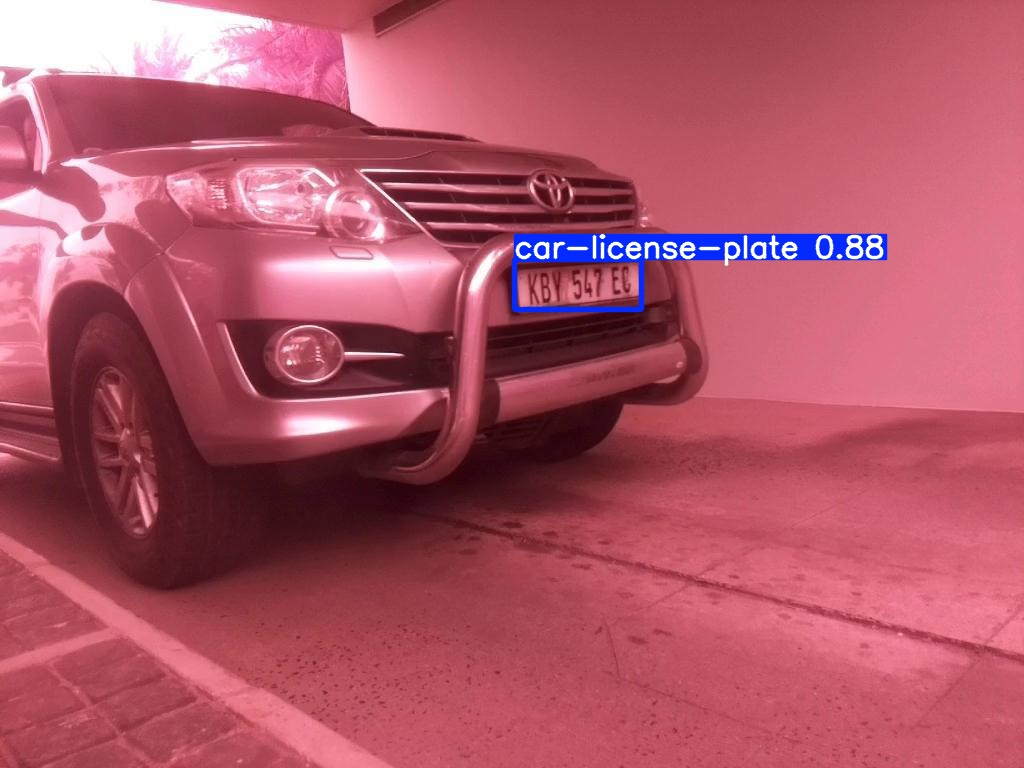

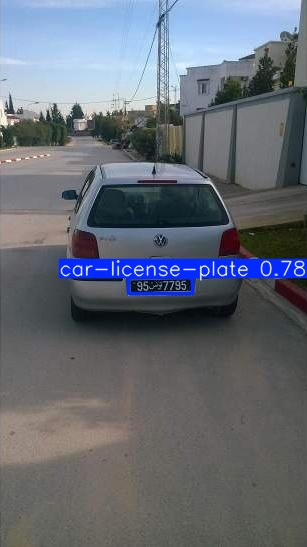

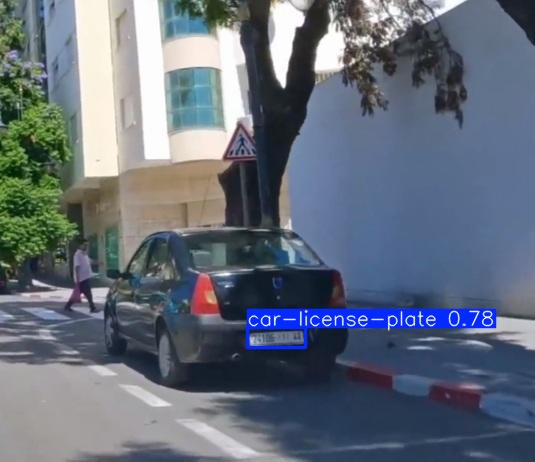

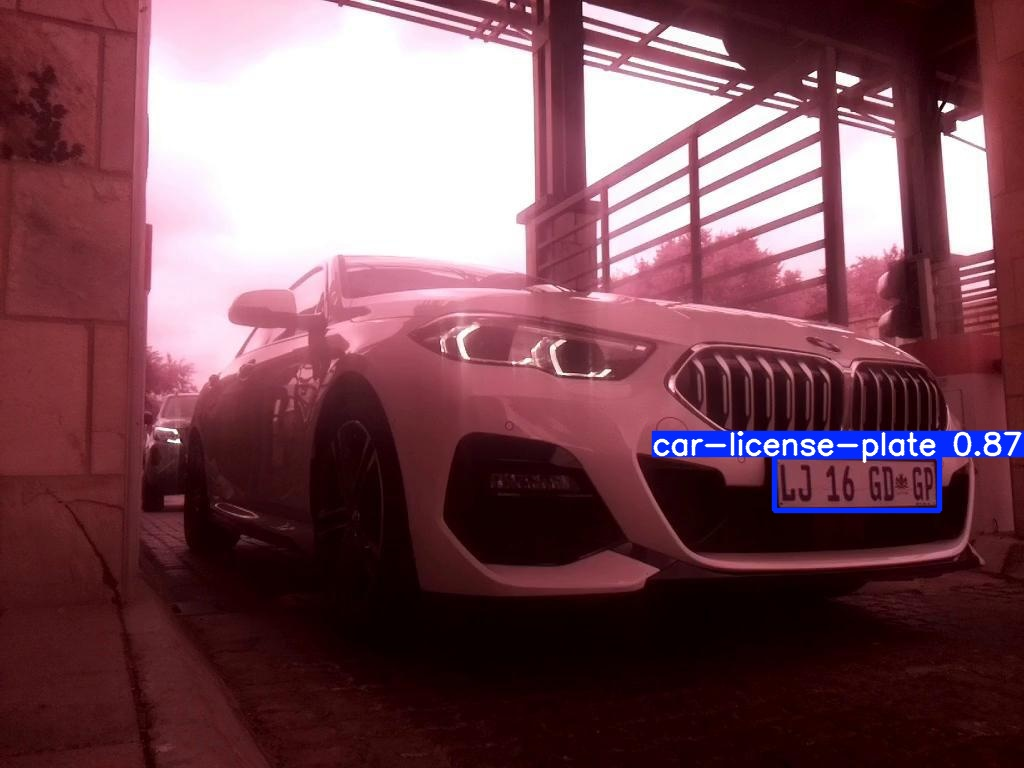

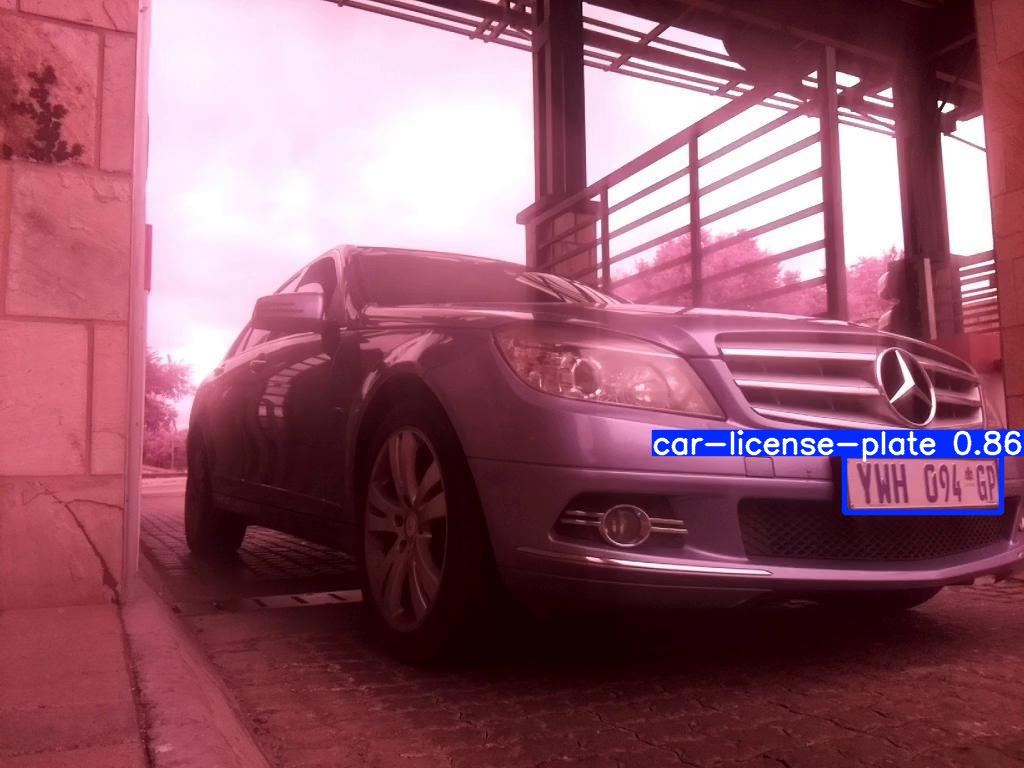

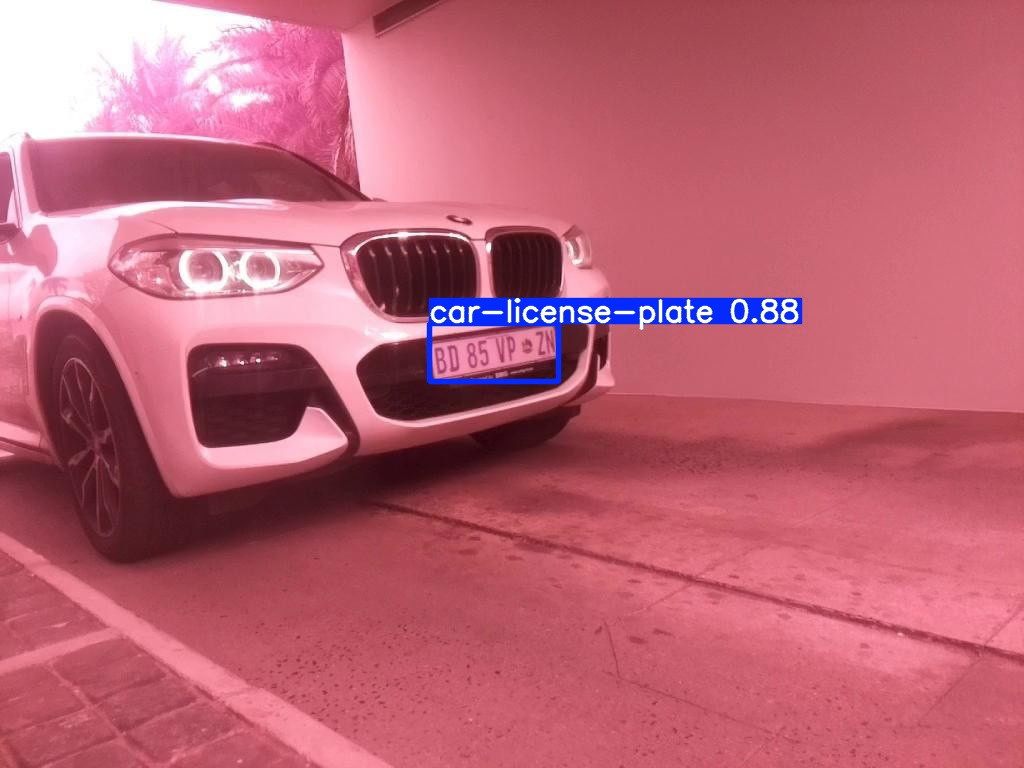

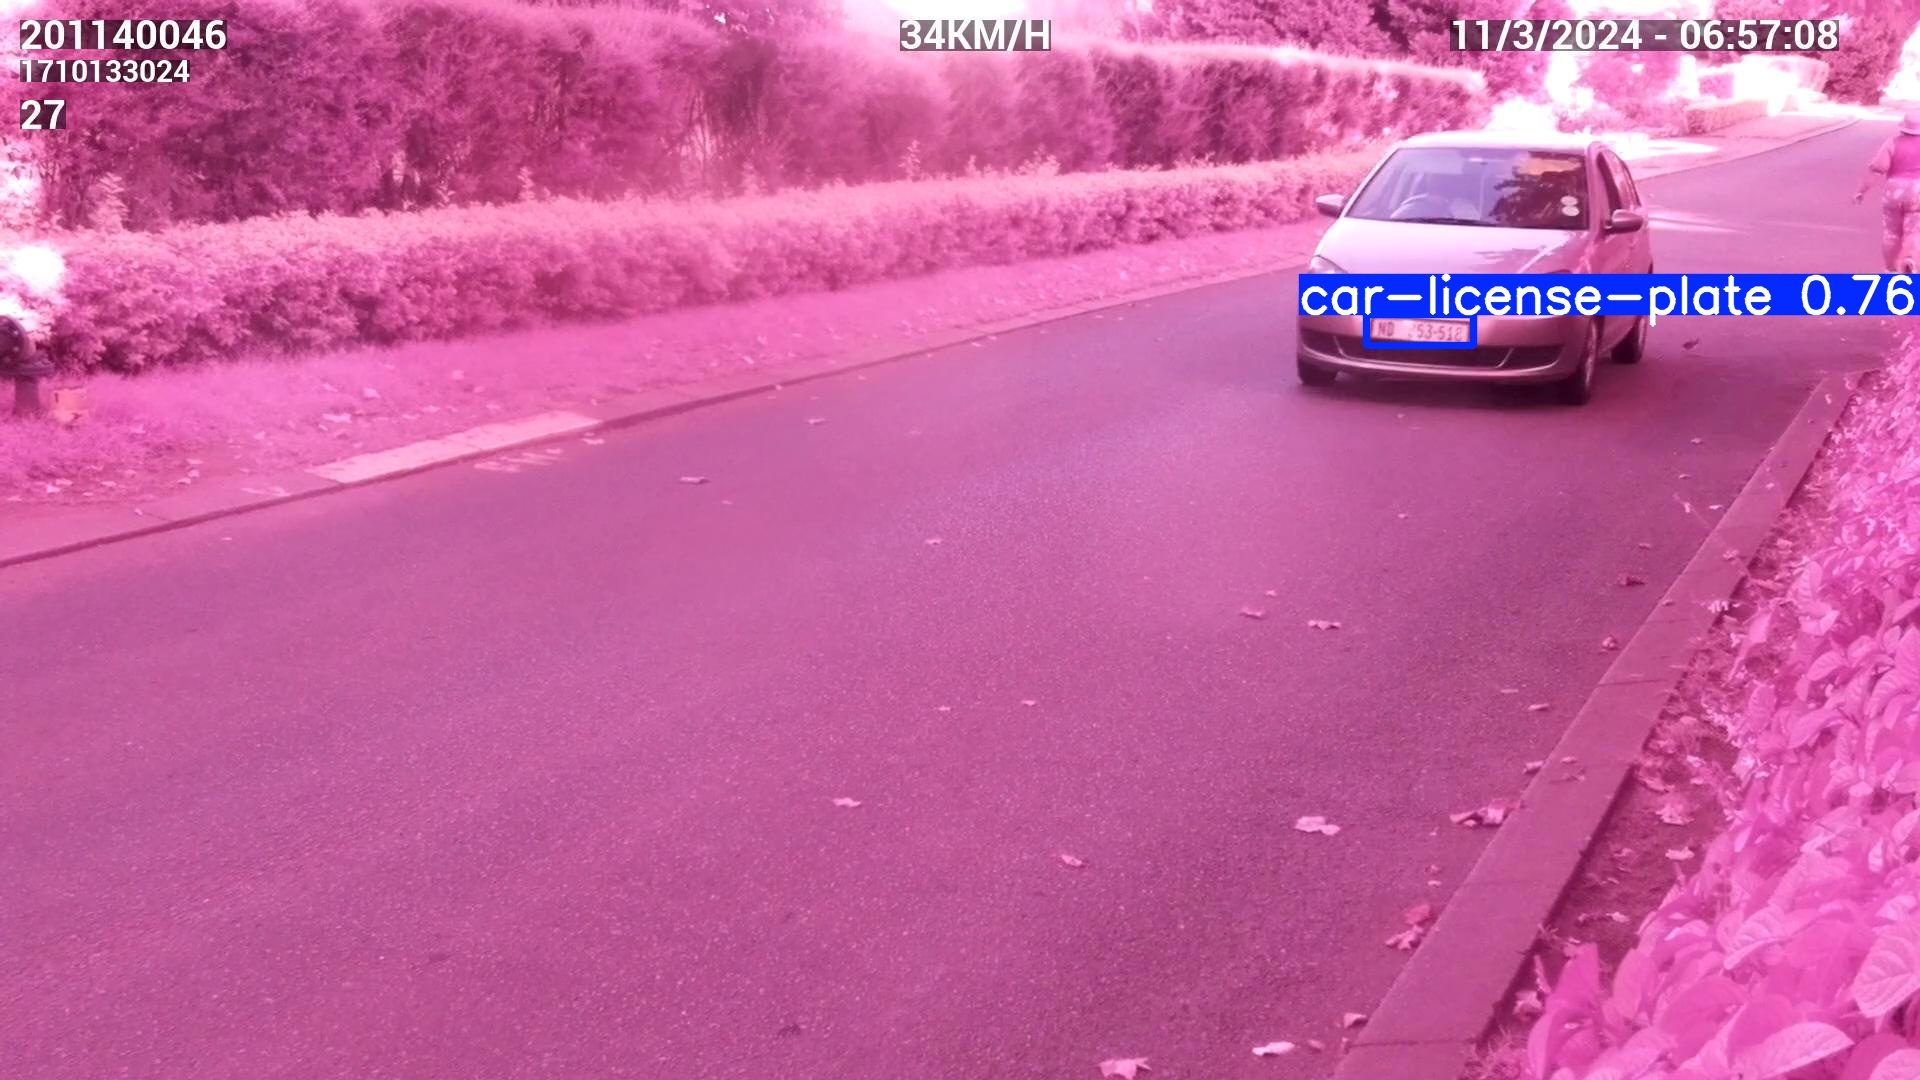

In [23]:
import glob
from IPython.display import Image, display

# Get all jpg images in the latest predict folder
image_paths = glob.glob('/content/runs/detect/predict/*.jpg')[:20]  # first 20 images

# Display them
for img_path in image_paths:
    display(Image(filename=img_path, width=600))

In [17]:
!zip -r /content/runs_backup.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 8%)
  adding: content/runs/detect/train/train_batch2661.jpg (deflated 11%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 5%)
  adding: content/runs/detect/train/args.yaml (deflated 53%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 34%)
  adding: content/runs/detect/train/labels.jpg (deflated 39%)
  adding: content/runs/detect/train/train_batch2662.jpg (deflated 14%)
  adding: content/runs/detect/train/results.csv (deflated 60%)
  adding: content/runs/detect/train/results.png (deflated 7%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 8%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 17%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 33%)
  adding: content/runs/detect/train/val_batch1_pred.

In [18]:
!ls -lh /content/runs_backup.zip

-rw-r--r-- 1 root root 90M Dec  4 05:34 /content/runs_backup.zip


In [19]:
from google.colab import files
files.download("/content/runs_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>